In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
df = pd.read_csv("/kaggle/input/datasets/shubhambathwal/flight-price-prediction/Clean_Dataset.csv")

/kaggle/input/datasets/shubhambathwal/flight-price-prediction/business.csv
/kaggle/input/datasets/shubhambathwal/flight-price-prediction/economy.csv
/kaggle/input/datasets/shubhambathwal/flight-price-prediction/Clean_Dataset.csv


## ✈️ Overview of the Project: Flight Price EDA and Prediction
Flight ticket prices are highly volatile and dynamic, heavily influenced by various factors such as airline brand, flight duration, number of stops, source, and destination.
The primary objective of this project is to uncover the underlying patterns in flight pricing through comprehensive Exploratory Data Analysis (EDA) and to build a robust machine learning 
model capable of accurately predicting future flight fares.

In this project, we dive deep into the data to clean, preprocess, and visualize the hidden relationships between features. After applying advanced feature engineering 
and transforming categorical data, we trained multiple regression models. Our final optimized predictive model achieved an outstanding R² score of 98.5%, demonstrating exceptional accuracy
in forecasting flight prices.

***Key Highlights & Objectives:***
* **Data Wrangling:** Handled missing values, parsed complex date/time features, and cleaned the raw dataset for modeling.
* **Exploratory Data:** Analysis (EDA): Visualized price distributions across different airlines, times of day, and routes to extract actionable business insights.
* **Feature Engineering:** Employed encoding techniques for categorical variables and created new meaningful features from existing time data.
* **Predictive Modeling:** Trained, evaluated, and tuned regression algorithms (e.g., Random Forest) to achieve a near-perfect R² score.

# What will we observe?
* Does price vary with Airlines?
* Does ticket price change based on the departure time and arrival time?
* Is the price changes with change in Source and Destination?
* Is the price affected when tickets are bought in just 1 or 2 days before departure?

## 📊 About the Dataset
This project utilizes a comprehensive flight price dataset containing **"300153** **records"** and **"11** **features"**. The data represents flight booking options, capturing various attributes that influence the final ticket fare. It includes domestic/international flights with detailed temporal and categorical information, providing an excellent foundation for time-series and regression-based machine learning tasks.

**Data Dictionary (Features):**

Here is a breakdown of the variables used in this dataset:

* airline: The name of the airline company (e.g., Indigo, Air India, Jet Airways).

* flight: flight number.
  
* source_city: The starting city of the journey.
  
* destination_city: The final destination city of the journey.

* departure_time: The departure time of the flight from the source.

* arrival_time: The arrival time of the flight at the destination.

* duration: The total time taken by the flight to reach the destination.
  
* stops: The number of layovers/stops between the source and destination (e.g., non-stop, 1 stop).

* days_left: total days left to the departure.

* class: the value of ticket (Economy or Business).

* price (Target Variable): The final ticket price charged to the passenger.


# Tools & Technologies

* Python

* Pandas

* Matplotlib

* Seaborn

* Scikit-Learn

* Kaggle Notebook

# ABOUT ME

* Second year Mathematics Student at Istanbul University. (3.28 GPA currently)

* Looking for an Erasmus+ internship. (between 2-4 months)

* Improving my Data Scientist & Machine Learning skills day by day.

* Learning German.

* English  with Professional working proficiency.

* Native Turkish.

* Active member on University clubs.

# First look to the data (Cleaning the Data)

In [2]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.drop(df.columns[df.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)

In [4]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [6]:
df.stops.unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [7]:
df.stops = df.stops.replace("zero", 0).replace("one", 1)

In [8]:
df.stops.unique()

array([0, 1, 'two_or_more'], dtype=object)

In [9]:
pd.set_option('future.no_silent_downcasting', True)
df.stops = df.stops.replace('two_or_more', 2)

In [10]:
df.stops.unique()

array([0, 1, 2], dtype=object)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [12]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,0,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,0,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,0,Morning,Mumbai,Economy,2.33,1,5955


In [13]:
df.departure_time.unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [14]:
df.days_left.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

# Graphs and EDA

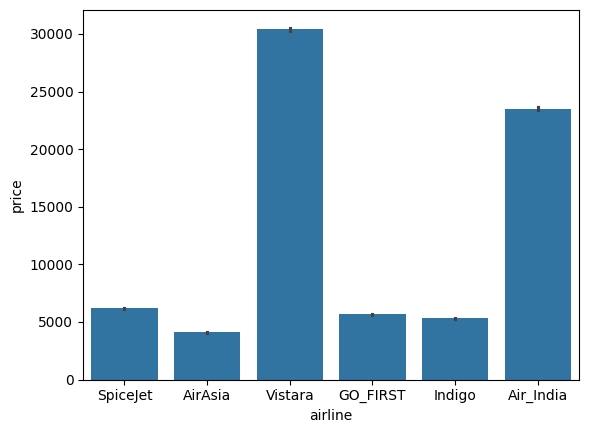

In [15]:
sns.barplot(x="airline",y="price", data=df)
plt.show()

In [16]:
df = pd.get_dummies(data=df, columns=["class"], drop_first=True)

In [17]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_Economy
0,SpiceJet,SG-8709,Delhi,Evening,0,Night,Mumbai,2.17,1,5953,True
1,SpiceJet,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,2.33,1,5953,True
2,AirAsia,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,2.17,1,5956,True
3,Vistara,UK-995,Delhi,Morning,0,Afternoon,Mumbai,2.25,1,5955,True
4,Vistara,UK-963,Delhi,Morning,0,Morning,Mumbai,2.33,1,5955,True


In [18]:
df_grouped = df.groupby(by=["airline","class_Economy","price","source_city","destination_city"])[["duration","days_left","stops","departure_time","arrival_time","source_city","destination_city"]].sum(numeric_only=True).sort_values(by="price",ascending=False).reset_index()

In [19]:
df_grouped

,airline,class_Economy,price,source_city,destination_city,duration,days_left
0,Vistara,False,123071,Kolkata,Delhi,13.50,3
1,Vistara,False,117307,Delhi,Kolkata,10.92,5
2,Vistara,False,116562,Delhi,Kolkata,21.08,1
3,Vistara,False,115211,Hyderabad,Mumbai,16.42,3
4,Vistara,False,114705,Kolkata,Hyderabad,9.50,17
...,...,...,...,...,...,...,...
21474,Indigo,True,1443,Chennai,Bangalore,117.46,4683
21475,SpiceJet,True,1106,Chennai,Hyderabad,8.75,263
21476,GO_FIRST,True,1105,Chennai,Hyderabad,38.75,1055
21477,Indigo,True,1105,Chennai,Hyderabad,1535.34,9570


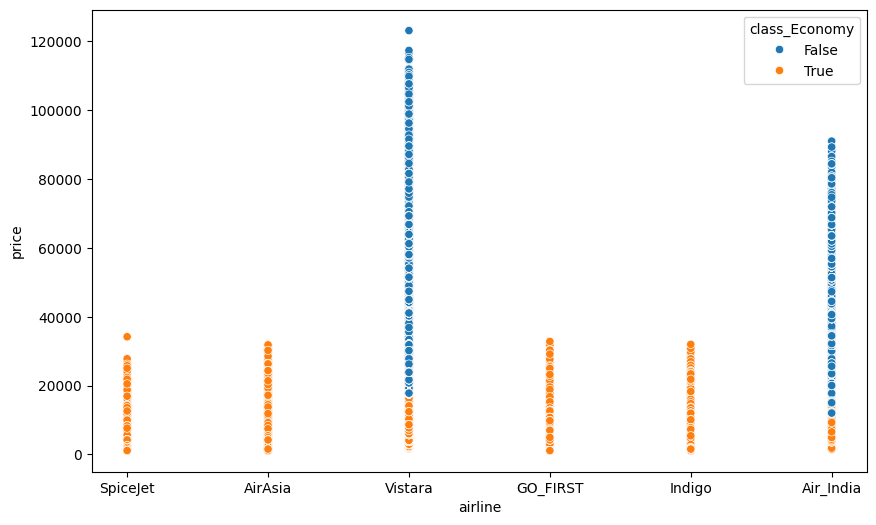

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="airline", y= "price", hue="class_Economy", data=df)
plt.show()

**Business Class is only available on Vistara and Air India.**

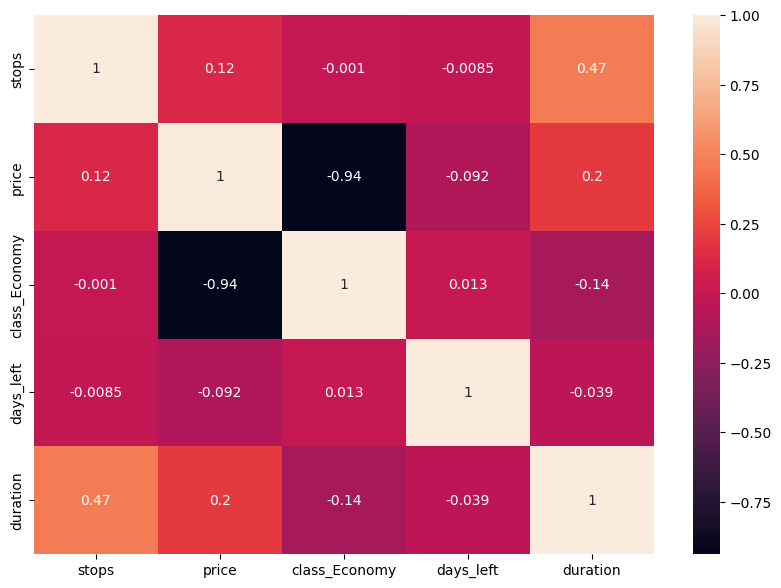

In [21]:
plt.figure(figsize=(10,7))
sns.heatmap(df[["stops","price","class_Economy","days_left","duration"]].corr(), annot=True)
plt.show()

# Detecting the outliers and understanding graphs

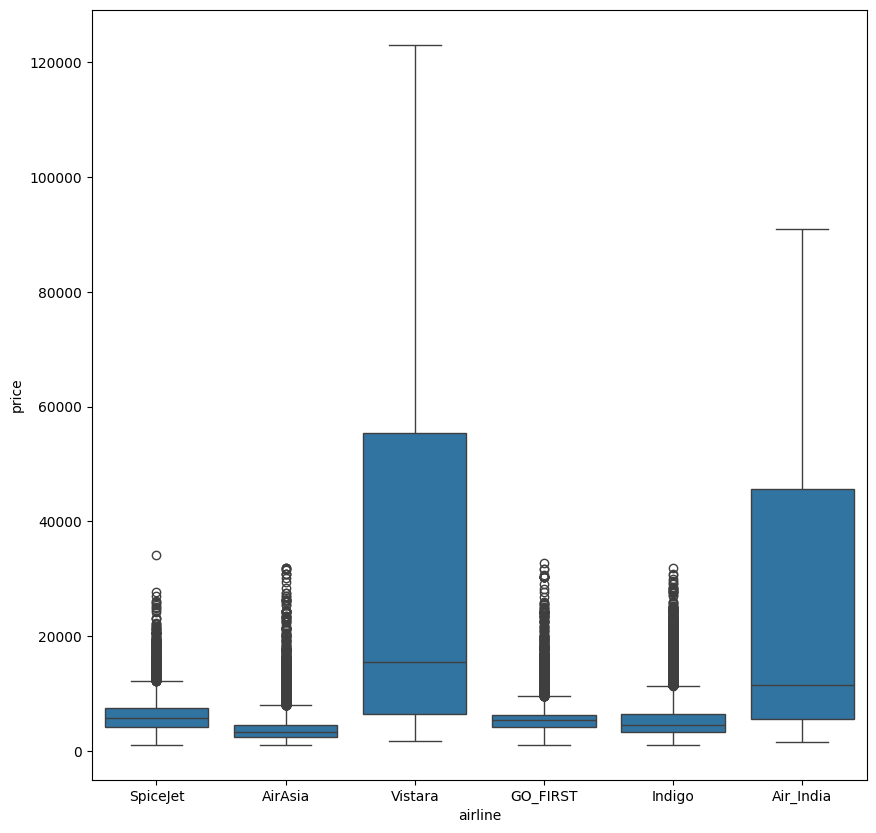

In [22]:
plt.figure(figsize=(10,10))
sns.boxplot(x=df["airline"],y=df["price"], data=df)
plt.show()

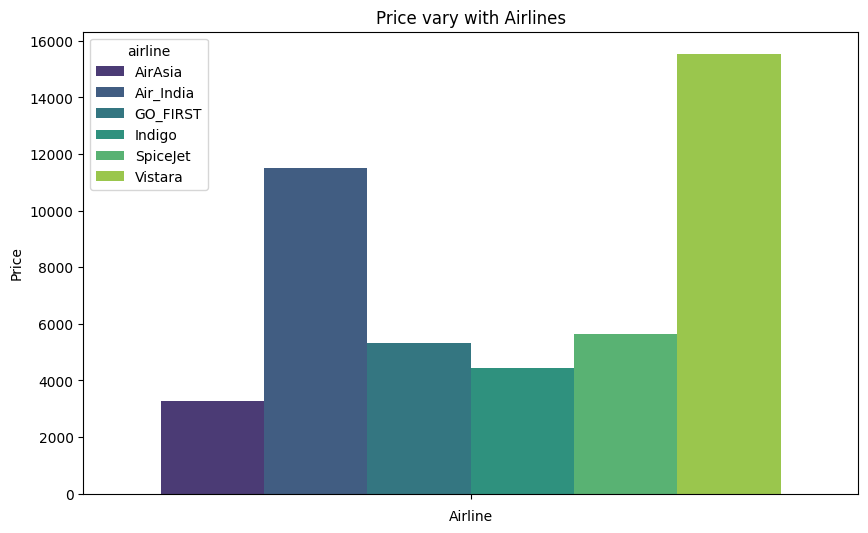

In [23]:
price = df.groupby("airline")["price"].median()
pd.set_option('future.no_silent_downcasting', True)

plt.figure(figsize=(10, 6))
sns.barplot(hue=price.index, y=price.values, palette="viridis")
plt.title("Price vary with Airlines")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.show()

**What is the graphs telling us:**
* Air Asia is the cheapest among all airlines.
* Otherwise Vistara is the most expensive among all airlines.
* There is a lot of outliers.
* Some outlier prices we have is more expensive then some Vistara tickets.

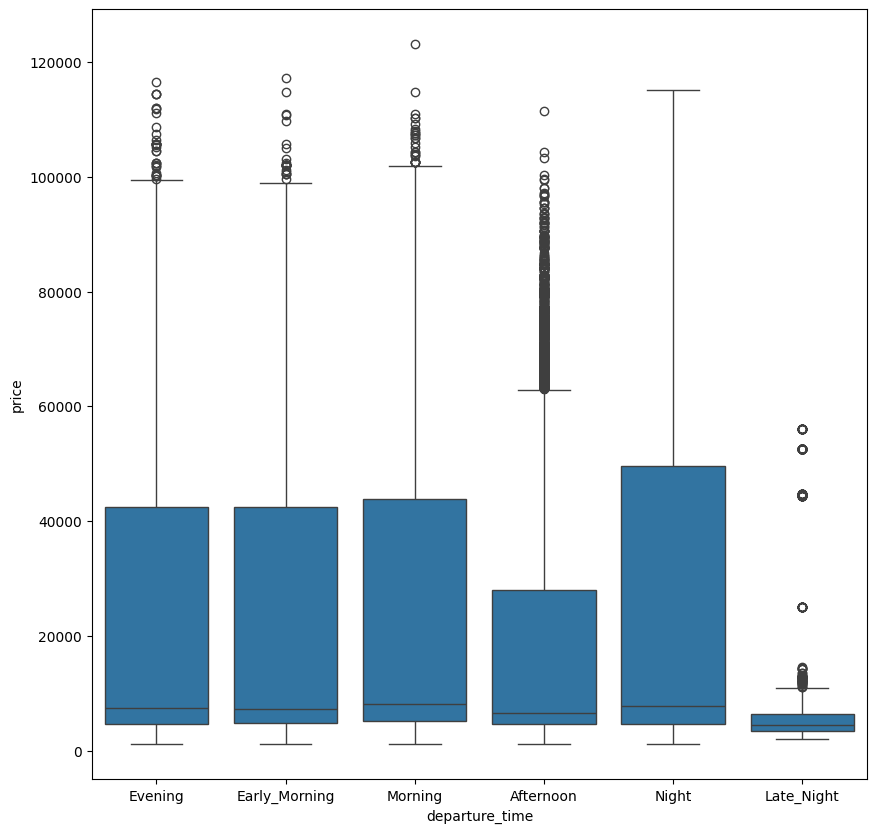

In [24]:
plt.figure(figsize=(10,10))
sns.boxplot(x=df["departure_time"],y=df["price"], data=df)
plt.show()

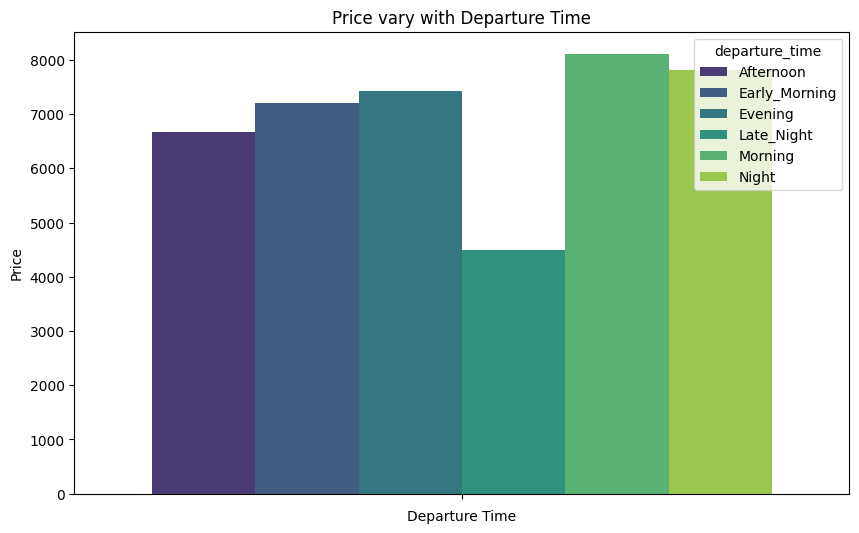

In [25]:
price = df.groupby("departure_time")["price"].median()
pd.set_option('future.no_silent_downcasting', True)

plt.figure(figsize=(10, 6))
sns.barplot(hue=price.index, y=price.values, palette="viridis")
plt.title("Price vary with Departure Time")
plt.xlabel("Departure Time")
plt.ylabel("Price")
plt.show()

**What is the graphs telling us:**
* Late night flights is the cheapest among all departure times.
* Otherwise morning flights is the most expensive among all departure times.
* There is a lot of outliers(espacially in afternoon).

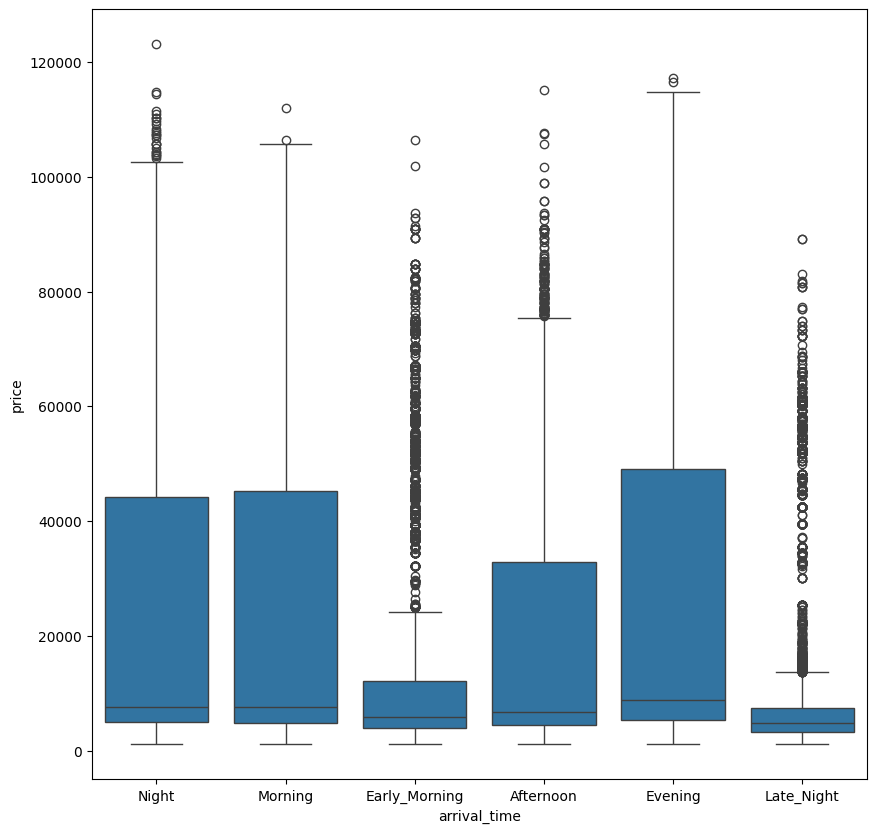

In [26]:
plt.figure(figsize=(10,10))
sns.boxplot(x=df["arrival_time"],y=df["price"], data=df)
plt.show()

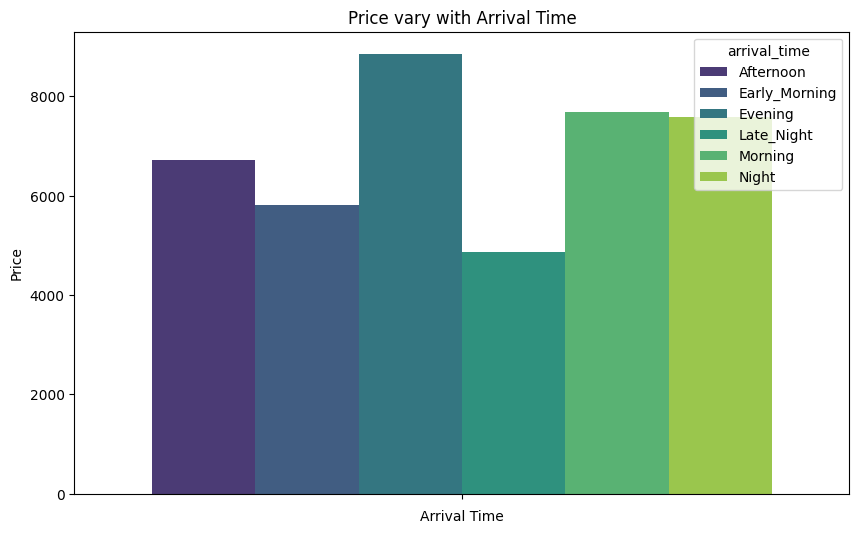

In [27]:
price = df.groupby("arrival_time")["price"].median()
pd.set_option('future.no_silent_downcasting', True)

plt.figure(figsize=(10, 6))
sns.barplot(hue=price.index, y=price.values, palette="viridis")
plt.title("Price vary with Arrival Time")
plt.xlabel("Arrival Time")
plt.ylabel("Price")
plt.show()

**What is the graphs telling us:**
* Late night is the cheapest among all arrival times.
* Otherwise evening is the most expensive among all arrival times.
* There is a lot of outliers again.

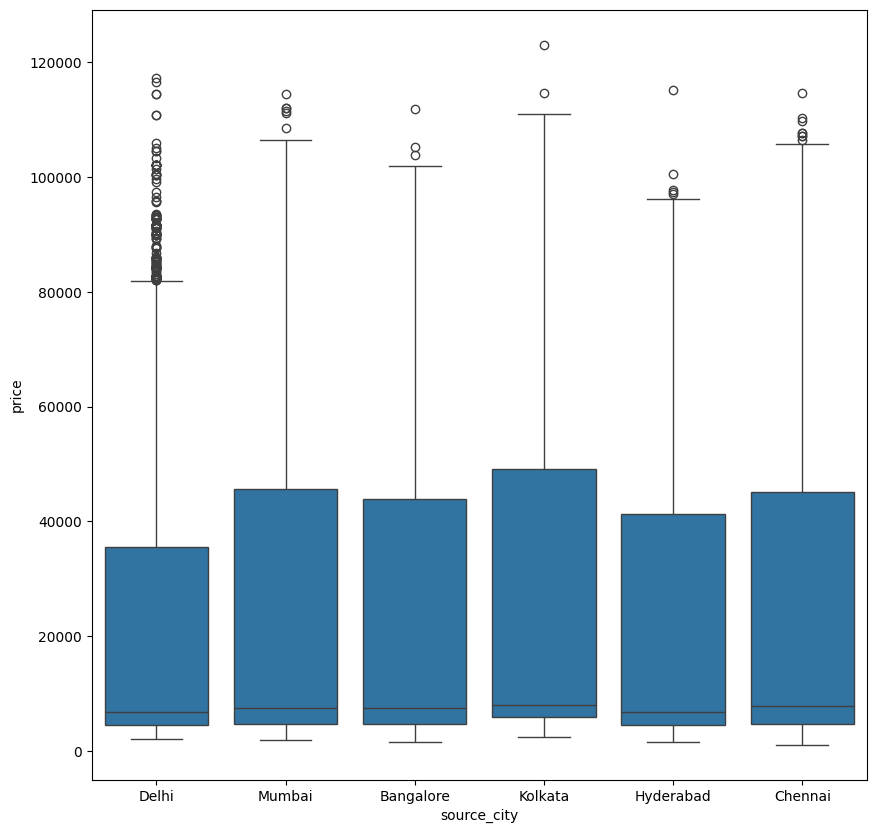

In [28]:
plt.figure(figsize=(10,10))
sns.boxplot(x=df["source_city"],y=df["price"], data=df)
plt.show()

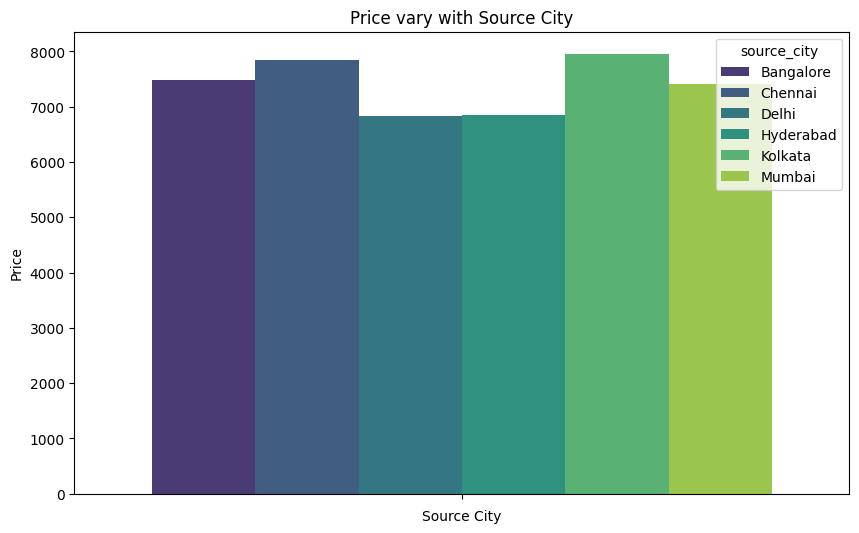

In [29]:
price = df.groupby("source_city")["price"].median()
pd.set_option('future.no_silent_downcasting', True)

plt.figure(figsize=(10, 6))
sns.barplot(hue=price.index, y=price.values, palette="viridis")
plt.title("Price vary with Source City")
plt.xlabel("Source City")
plt.ylabel("Price")
plt.show()

**What is the graphs telling us:**
* Delhi is the cheapest among all source cities.
* Otherwise Kolkata is the most expensive among all source cities.
* There is a lot of outliers in Delhi.

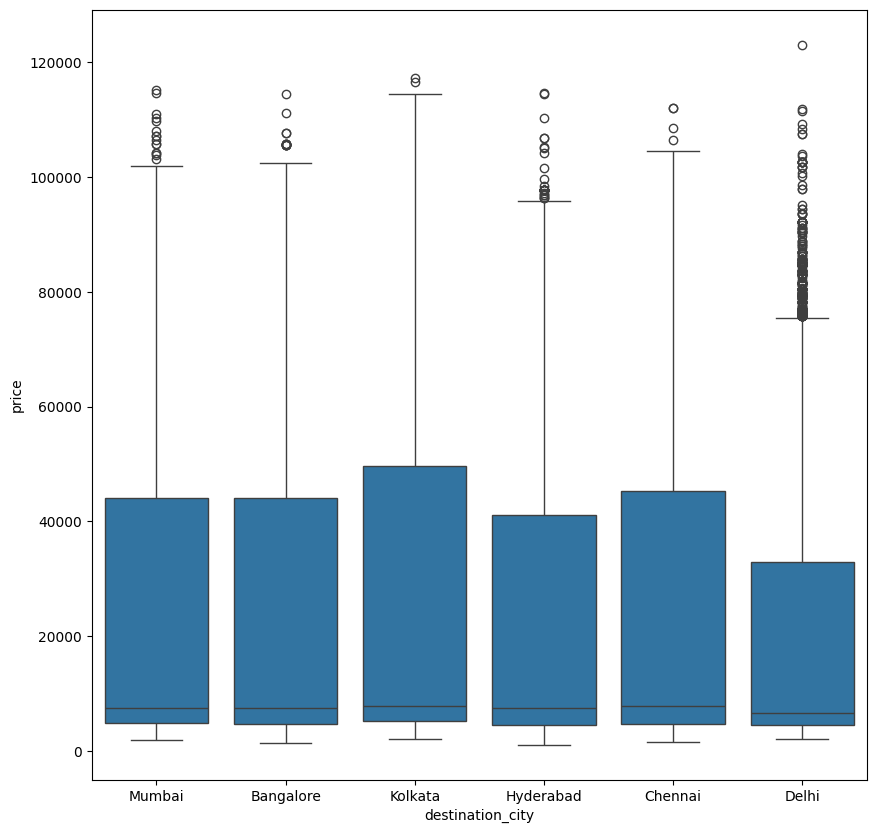

In [30]:
plt.figure(figsize=(10,10))
sns.boxplot(x=df["destination_city"],y=df["price"], data=df)
plt.show()

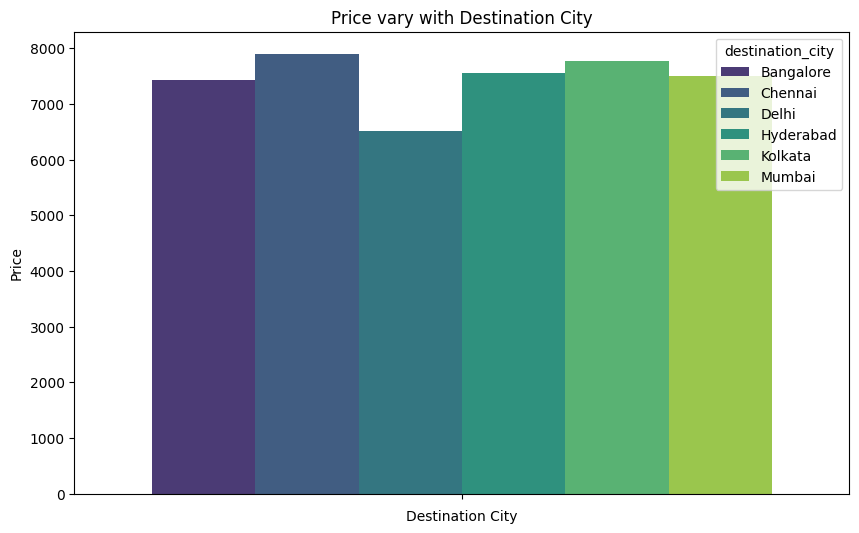

In [31]:
price = df.groupby("destination_city")["price"].median()
pd.set_option('future.no_silent_downcasting', True)

plt.figure(figsize=(10, 6))
sns.barplot(hue=price.index, y=price.values, palette="viridis")
plt.title("Price vary with Destination City")
plt.xlabel("Destination City")
plt.ylabel("Price")
plt.show()

**What is the graphs telling us:**
* Delhi is the cheapest among all destination cities.
* Otherwise Chennai is the most expensive among all destination cities.
* There is a lot of outliers in Delhi again.

# Encoding columns of the data

In [32]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
 10  class_Economy     300153 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 23.2+ MB


In [34]:
df["airline"] = encoder.fit_transform(df["airline"])
df["source_city"] = encoder.fit_transform(df["source_city"])
df["departure_time"] = encoder.fit_transform(df["departure_time"])
df["arrival_time"] = encoder.fit_transform(df["arrival_time"])
df["destination_city"] = encoder.fit_transform(df["destination_city"])

In [35]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_Economy
0,4,SG-8709,2,2,0,5,5,2.17,1,5953,True
1,4,SG-8157,2,1,0,4,5,2.33,1,5953,True
2,0,I5-764,2,1,0,1,5,2.17,1,5956,True
3,5,UK-995,2,4,0,0,5,2.25,1,5955,True
4,5,UK-963,2,4,0,4,5,2.33,1,5955,True


In [36]:
df.drop(["flight"], axis=1, inplace=True)

In [37]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_Economy
0,4,2,2,0,5,5,2.17,1,5953,True
1,4,2,1,0,4,5,2.33,1,5953,True
2,0,2,1,0,1,5,2.17,1,5956,True
3,5,2,4,0,0,5,2.25,1,5955,True
4,5,2,4,0,4,5,2.33,1,5955,True


**Seeking Pairplot**

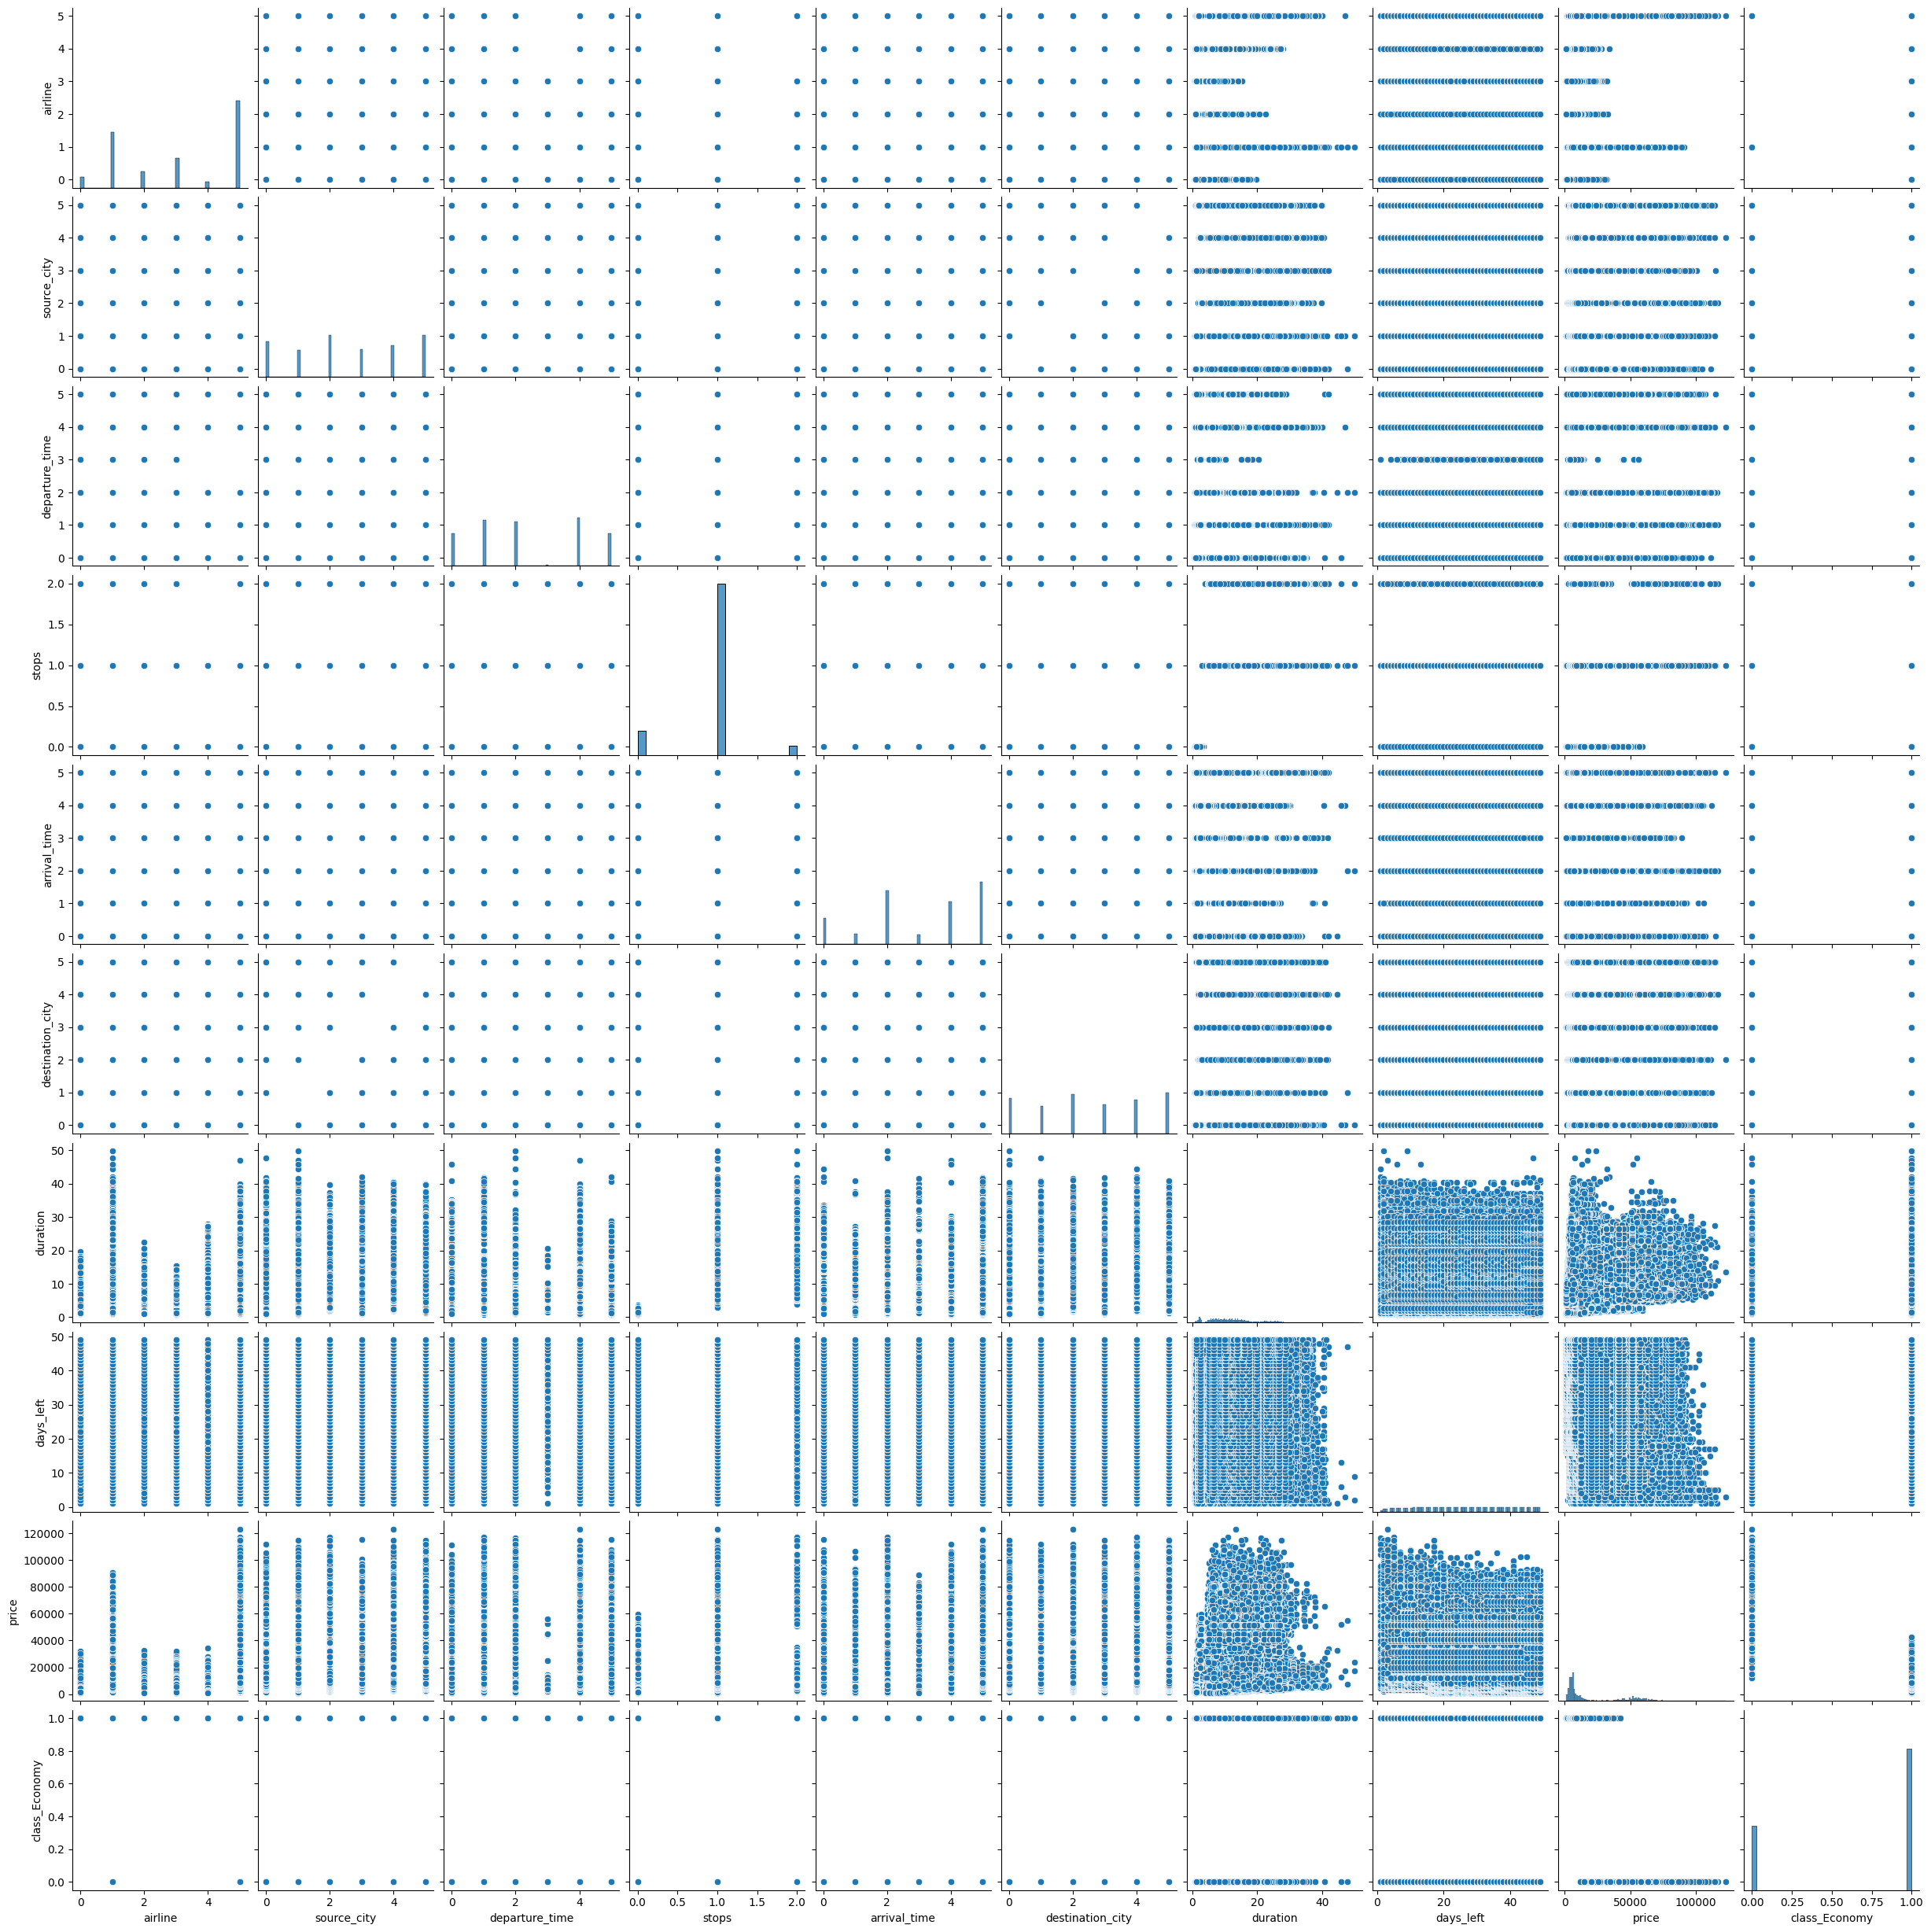

In [38]:
sns.pairplot(df)
plt.show()

**Seeking heatmap**

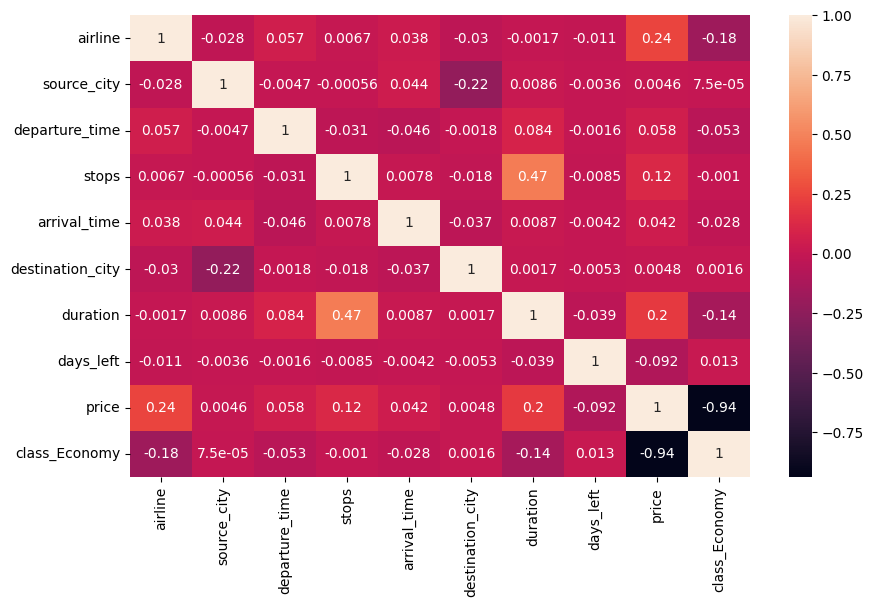

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [40]:
X= df.drop(["price"], axis=1)
y= df["price"]

In [41]:
X

,airline,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_Economy
0,4,2,2,0,5,5,2.17,1,True
1,4,2,1,0,4,5,2.33,1,True
2,0,2,1,0,1,5,2.17,1,True
3,5,2,4,0,0,5,2.25,1,True
4,5,2,4,0,4,5,2.33,1,True
...,...,...,...,...,...,...,...,...,...
300148,5,1,4,1,2,3,10.08,49,False
300149,5,1,0,1,5,3,10.42,49,False
300150,5,1,1,1,5,3,13.83,49,False
300151,5,1,1,1,2,3,10.00,49,False


In [42]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

# Regression and Model Choosing/Comparison

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
scaler = StandardScaler()
linear = LinearRegression()
lasso = Lasso()
ridge = Ridge()
elasticnet = ElasticNet()
lassocv = LassoCV(cv=5)
ridgecv = RidgeCV(cv=5)
elasticnetcv = ElasticNetCV(cv=5)
forestregressor = RandomForestRegressor(random_state=42)

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.25, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((225114, 9), (225114,), (75039, 9), (75039,))

In [45]:
X_train.corr()

,airline,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_Economy
airline,1.000000,-0.027537,0.058522,0.005202,0.038014,-0.031498,-0.001336,-0.010308,-0.178014
source_city,-0.027537,1.000000,-0.006169,-0.001131,0.045822,-0.222917,0.008402,-0.002149,0.000493
departure_time,0.058522,-0.006169,1.000000,-0.032576,-0.046953,-0.002067,0.083352,-0.002189,-0.052249
stops,0.005202,-0.001131,-0.032576,1.000000,0.006680,-0.015394,0.468253,-0.010928,0.000136
arrival_time,0.038014,0.045822,-0.046953,0.006680,1.000000,-0.038182,0.008326,-0.003222,-0.028731
destination_city,-0.031498,-0.222917,-0.002067,-0.015394,-0.038182,1.000000,0.002049,-0.005402,0.002519
duration,-0.001336,0.008402,0.083352,0.468253,0.008326,0.002049,1.000000,-0.040802,-0.136341
days_left,-0.010308,-0.002149,-0.002189,-0.010928,-0.003222,-0.005402,-0.040802,1.000000,0.013047
class_Economy,-0.178014,0.000493,-0.052249,0.000136,-0.028731,0.002519,-0.136341,0.013047,1.000000


In [46]:
def correlation_for_dropping(data, threshold):
    columns_to_drop = set()
    corr = data.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [47]:
columns_dropping = correlation_for_dropping(X_train, 0.85)

In [48]:
columns_dropping

set()

**no high correlation.(No need to drop)**

**Scaling the train and test**

In [49]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Linear Regression**

Mean Absolute Eror:  4528.2555869501375
Mean Squared Eror:  48203557.82959329
r2 score:  0.9065130455732191


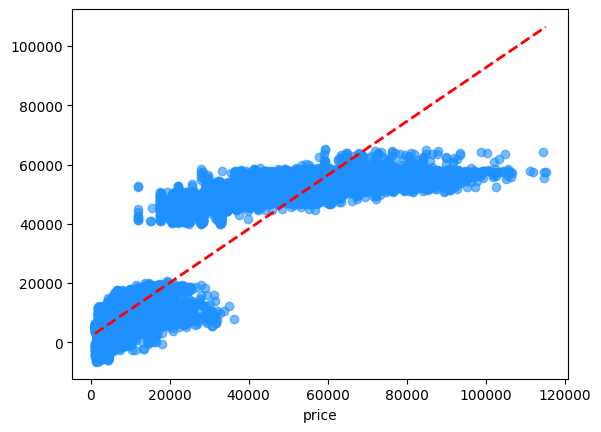

In [50]:
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**Ridge**

Mean Absolute Eror:  4528.259863191723
Mean Squared Eror:  48203555.01402684
r2 score:  0.9065130510337855


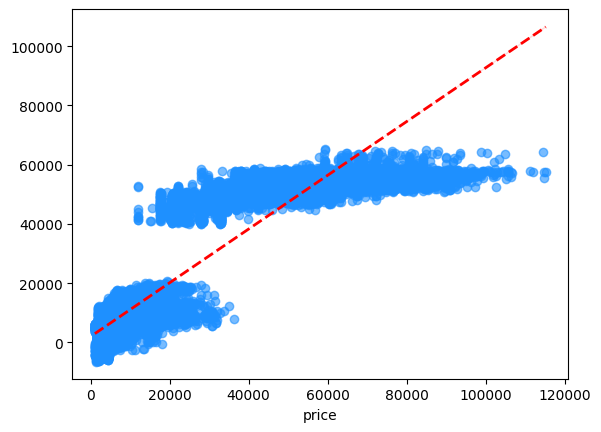

In [51]:
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**Lasso**

Mean Absolute Eror:  4527.832521260303
Mean Squared Eror:  48203484.397535674
r2 score:  0.906513187988836


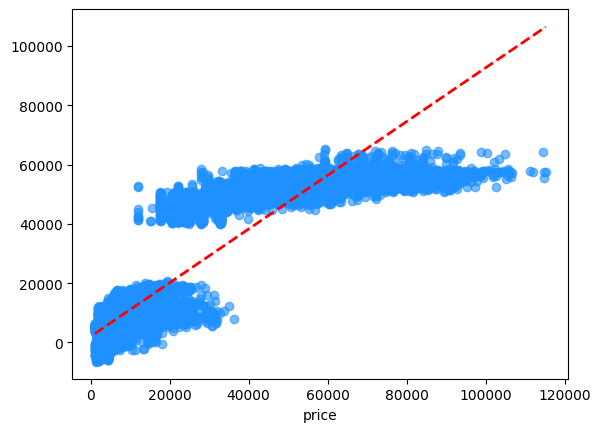

In [52]:
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**ElasticNet**

Mean Absolute Eror:  7471.340269671067
Mean Squared Eror:  96946031.1026145
r2 score:  0.811980907641981


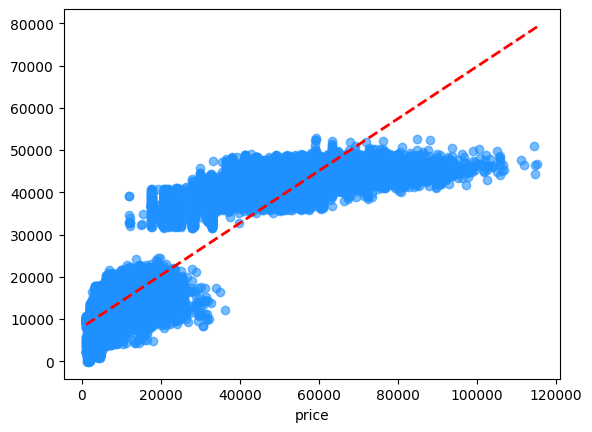

In [53]:
elasticnet.fit(X_train_scaled, y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**RidgeCV**

Mean Absolute Eror:  4528.256014469637
Mean Squared Eror:  48203557.54721265
r2 score:  0.9065130461208738


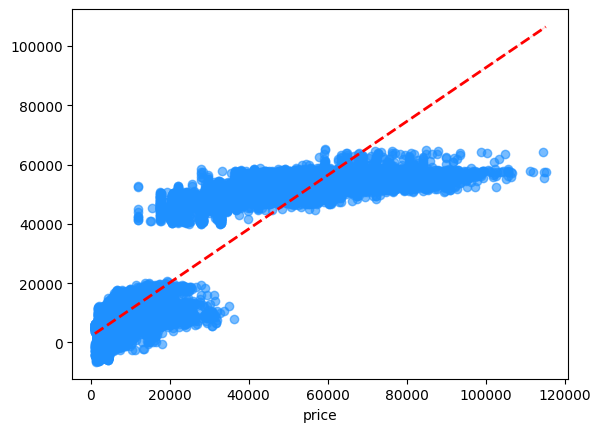

In [54]:
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**LassoCV**

Mean Absolute Eror:  4519.557478473497
Mean Squared Eror:  48205613.94973476
r2 score:  0.9065090578922549


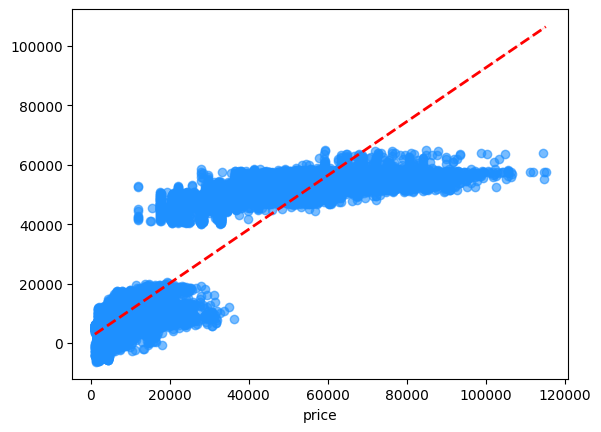

In [55]:
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**ElasticNetCV**

Mean Absolute Eror:  18832.920541759817
Mean Squared Eror:  470505845.71208096
r2 score:  0.08749145216382337


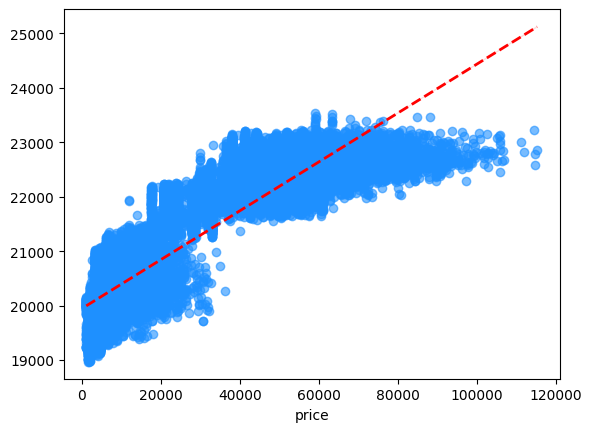

In [56]:
elasticnetcv.fit(X_train_scaled, y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.show()

**Seeking best predictive regression**

In [57]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.5 MB/s eta 0:00:00


In [58]:
from lazypredict.Supervised import LazyClassifier, LazyRegressor

In [59]:
reg = LazyRegressor(verbose=0, ignore_warnings= True, custom_metric= None)
X_train_mini = X_train_scaled[:20000]
y_train_mini = y_train[:20000]

X_test_mini = X_test_scaled[:5000]
y_test_mini = y_test[:5000]
models, predictions = reg.fit(X_train_mini, X_test_mini, y_train_mini, y_test_mini)

In [60]:
print(models)

                               Adjusted R-Squared     R-Squared  \
Model                                                             
RandomForestRegressor                    0.971584  9.716353e-01   
ExtraTreesRegressor                      0.971181  9.712329e-01   
BaggingRegressor                         0.969789  9.698431e-01   
XGBRegressor                             0.967124  9.671833e-01   
CatBoostRegressor                        0.964763  9.648268e-01   
LGBMRegressor                            0.963187  9.632531e-01   
HistGradientBoostingRegressor            0.962599  9.626661e-01   
DecisionTreeRegressor                    0.953975  9.540581e-01   
ExtraTreeRegressor                       0.951226  9.513141e-01   
KNeighborsRegressor                      0.949410  9.495008e-01   
GradientBoostingRegressor                0.949388  9.494796e-01   
AdaBoostRegressor                        0.935217  9.353341e-01   
PoissonRegressor                         0.919452  9.195970e-0

# Best model that explains and predicts the data

Mean Absolute Eror:  1098.8335953515812
Mean Squared Eror:  7852804.711037319
r2 score:  0.9847701118092065


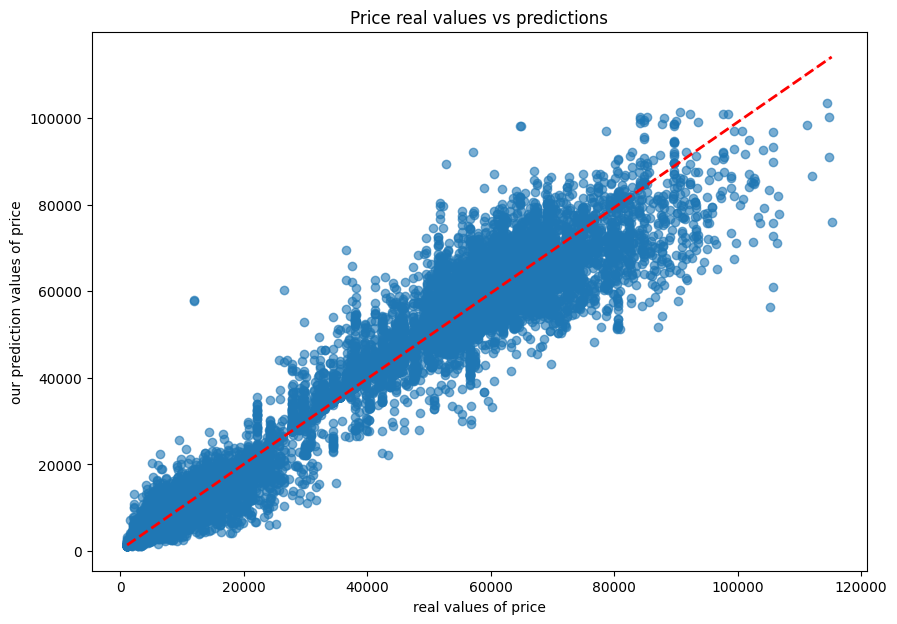

In [61]:
forestregressor.fit(X_train_scaled, y_train)
y_pred = forestregressor.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Eror: ", mae)
print("Mean Squared Eror: ", mse)
print("r2 score: ", r2)
plt.figure(figsize=(10,7))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})
plt.xlabel("real values of price")
plt.ylabel("our prediction values of price")
plt.title("Price real values vs predictions")
plt.show()